In [23]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

conexao = ("Server=DESKTOP-OICCGK1;"
           "Driver=SQL Server;"
           "Database=ContosoRetailDW;"
           "Trusted connection=yes")

dados = pyodbc.connect(conexao)

comando_sql = """
SELECT 
	RIGHT(CalendarMonth,2) AS 'Mês',
	CalendarYear AS 'Ano',
	(SUM(SalesAmount) - SUM(DiscountAmount)) AS 'Total Faturado'
FROM FactSales AS f
LEFT JOIN DimDate AS d
	ON f.DateKey = d.Datekey
GROUP BY
	CalendarMonth,
	CalendarYear
ORDER BY 
	CalendarYear,
	CalendarMonth 
"""

In [24]:
tabela = pd.read_sql(comando_sql,dados)
tabela["Total Faturado"] = pd.to_numeric(tabela["Total Faturado"])
#display(tabela)

vendas_2007 = tabela[tabela["Ano"] == 2007]
display(vendas_2007)

vendas_2008 = tabela[tabela["Ano"] == 2008]
display(vendas_2008)

vendas_2009 = tabela[tabela["Ano"] == 2009]
display(vendas_2009)

C:\Users\usu\AppData\Local\Temp\ipykernel_14776\601118533.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tabela = pd.read_sql(comando_sql,dados)


,Mês,Ano,Total Faturado
0,01,2007,2.634282e+08
1,02,2007,2.928843e+08
2,03,2007,2.947441e+08
3,04,2007,3.977448e+08
4,05,2007,4.221731e+08
5,06,2007,4.085913e+08
6,07,2007,3.851680e+08
7,08,2007,3.818186e+08
8,09,2007,3.726426e+08
9,10,2007,4.191391e+08


,Mês,Ano,Total Faturado
12,01,2008,2.734619e+08
13,02,2008,2.835911e+08
14,03,2008,2.847113e+08
15,04,2008,3.525112e+08
16,05,2008,3.496281e+08
17,06,2008,3.367394e+08
18,07,2008,3.821147e+08
19,08,2008,3.546627e+08
20,09,2008,3.482616e+08
21,10,2008,3.234016e+08


,Mês,Ano,Total Faturado
24,01,2009,2.639038e+08
25,02,2009,2.606479e+08
26,03,2009,2.652144e+08
27,04,2009,3.059309e+08
28,05,2009,3.398421e+08
29,06,2009,3.296038e+08
30,07,2009,3.299704e+08
31,08,2009,3.203406e+08
32,09,2009,3.093172e+08
33,10,2009,3.242930e+08


In [25]:
from cycler import cycler

cores = plt.get_cmap("Set2").colors
ciclo = cycler(color = cores)
plt.rc("axes", prop_cycle=ciclo)

def format_money(valor):
    return "R${:,.2f}".format(valor).replace(",","x").replace(".",",").replace("x",".")

meses = np.arange(len(vendas_2007["Mês"])) + 1
print(meses)
largura = 0.3
p2007 = meses 
p2008 = meses + largura
p2009 = meses - largura


[ 1  2  3  4  5  6  7  8  9 10 11 12]


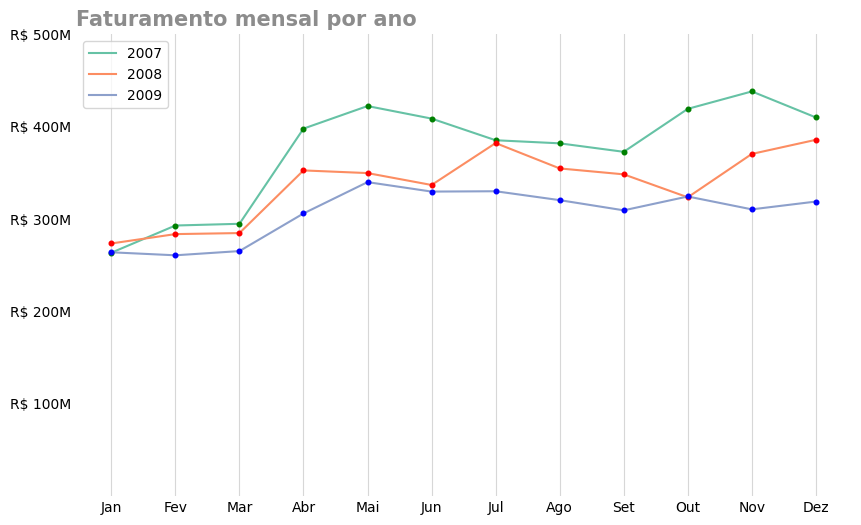

In [26]:
plt.figure(figsize=(10,6))
plt.title("Faturamento mensal por ano",fontsize=15,color="gray",alpha=0.9,loc="left",fontweight="bold")
plt.box(False)
plt.grid(axis="x",alpha=0.5)


plt.plot(meses,vendas_2007["Total Faturado"],label="2007")
plt.scatter(meses,vendas_2007["Total Faturado"],zorder=5,s=11,color="green",alpha=1)

plt.plot(meses,vendas_2008["Total Faturado"],label="2008")
plt.scatter(meses,vendas_2008["Total Faturado"],zorder=5,s=11,color="red",alpha=1)

plt.plot(meses,vendas_2009["Total Faturado"],label="2009")
plt.scatter(meses,vendas_2009["Total Faturado"],zorder=5,s=11,color="blue",alpha=1)

plt.tick_params("x",length=0)
plt.tick_params("y",length=0)
plt.xticks(meses,["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"])
plt.yticks([100000000,200000000,300000000,400000000,500000000],["R$ 100M","R$ 200M","R$ 300M","R$ 400M","R$ 500M"])
plt.ylim(0,500000000)


plt.legend()



In [27]:
lojas_fechadas = [
"Contoso Buffalo Store"
,"Contoso Trenton No.2 Store "
,"Contoso North Bend Store"
,"Contoso Cheney Store"
,"Contoso Sedalia Store"
,"Contoso Milwaukee No.2 Store"
,"Contoso Stoughton Store"
,"Contoso Humble Store"
,"Contoso Key West Store"
,"Contoso Worcester No.2 Store"
,"Contoso Pittsfield Store"
,"Contoso Alexandria Store"]

for loja in lojas_fechadas:
	query = f""" WITH vendas AS (
				SELECT 
				StoreName AS 'Nome_Loja',
				SUM(SalesAmount) - SUM(DiscountAmount) AS 'Vendas_ano',
				CalendarYear AS 'Ano'
			FROM FactSales AS f
			JOIN DimStore AS d
				ON f.StoreKey = d.StoreKey
			JOIN DimDate AS dd
				ON f.DateKey = dd.Datekey
			GROUP BY CalendarYear,StoreName)

			SELECT 
				Nome_Loja,
				Ano,
				FORMAT(Vendas_ano,'C','pt-br'),
				FORMAT((Vendas_ano - LAG(Vendas_ano) OVER(ORDER BY Ano)) / LAG(Vendas_ano) OVER(ORDER BY Ano),'P2','pt-br') AS 'YoY'
			FROM vendas
			WHERE Nome_Loja = '{loja}'"""
	df = pd.read_sql(query,dados)
	print(f"====={loja}=====")
	display(df)							


=====Contoso Buffalo Store=====


C:\Users\usu\AppData\Local\Temp\ipykernel_14776\3781828342.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,dados)


,Nome_Loja,Ano,,YoY
0,Contoso Buffalo Store,2007,"R$ 9.256.793,91",None
1,Contoso Buffalo Store,2008,"R$ 7.314.274,17","-20,98%"
2,Contoso Buffalo Store,2009,"R$ 5.489.793,85","-24,94%"


=====Contoso Trenton No.2 Store =====


C:\Users\usu\AppData\Local\Temp\ipykernel_14776\3781828342.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,dados)


...

=====Contoso Pittsfield Store=====


,Nome_Loja,Ano,,YoY
0,Contoso Pittsfield Store,2007,"R$ 9.389.646,18",None
1,Contoso Pittsfield Store,2008,"R$ 7.455.124,15","-20,60%"
2,Contoso Pittsfield Store,2009,"R$ 5.609.181,21","-24,76%"


=====Contoso Alexandria Store=====


C:\Users\usu\AppData\Local\Temp\ipykernel_14776\3781828342.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,dados)


,Nome_Loja,Ano,,YoY
0,Contoso Alexandria Store,2007,"R$ 9.216.038,46",None
1,Contoso Alexandria Store,2008,"R$ 7.065.194,58","-23,33%"
2,Contoso Alexandria Store,2009,"R$ 5.714.523,34","-19,11%"
